In [17]:
from astropy.table import Table
from astropy.coordinates import SkyCoord
import numpy as np
from astropy import units as u
kang09_fits = Table.read('/orange/adamginsburg/w51/TaehwaYoo/kang09.fit')
print(kang09_fits.colnames)

skycoord_gal = SkyCoord(kang09_fits['_Glon'], kang09_fits['_Glat'], unit='deg', frame='galactic')
skycoord_icrs = skycoord_gal.transform_to('icrs')
stage_kang09 = kang09_fits['Stg']
class1_kang09 = kang09_fits['Cl1']
class2_kang09 = kang09_fits['Cl2']
catalog_jwst = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_refined.fits')
skycoord_jwst = catalog_jwst['skycoord_ref']
idx, d2d, _ = skycoord_icrs.match_to_catalog_sky(skycoord_jwst, nthneighbor=1)
d2d_constraint = 0.1 * u.arcsec
idx = idx[d2d < d2d_constraint]

print(f'Matched {len(idx)} sources with a separation less than {d2d_constraint}.')



['SSTGLMC', 'Stg', 'Cl1', 'Cl2', 'Jmag', 'Hmag', 'Ksmag', '__3_6_', '__4_5_', '__5_8_', '__8_0_', '__24_', 'A', '_Glon', '_Glat']
Matched 1 sources with a separation less than 0.1 arcsec.


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


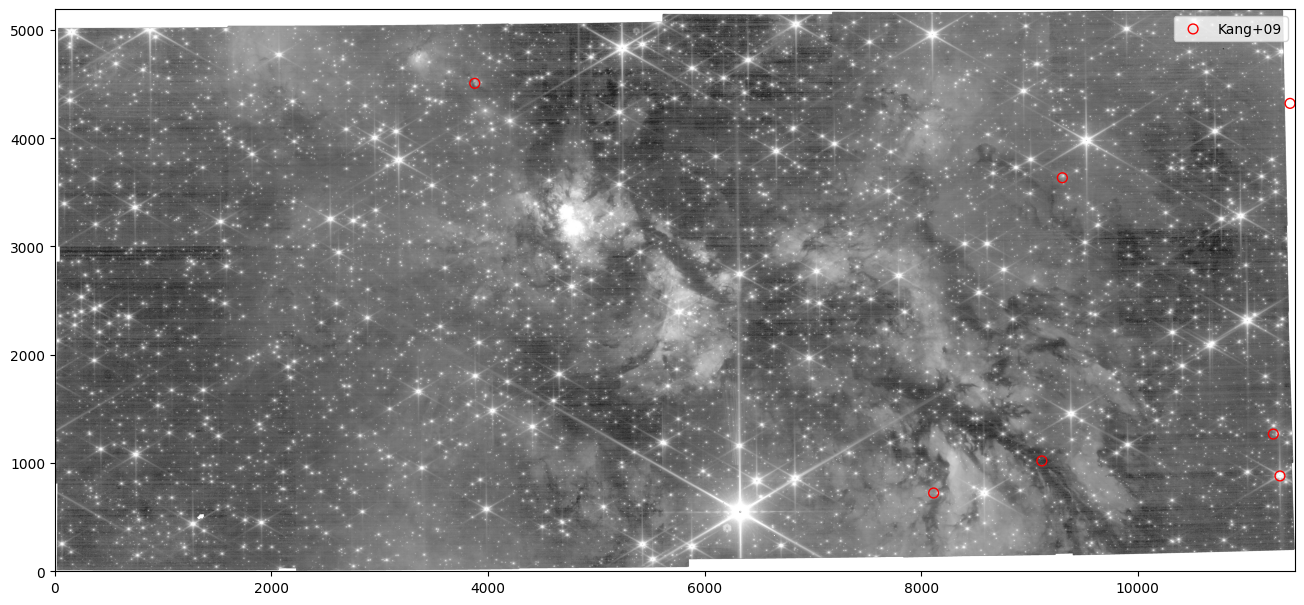

In [18]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

file_f140m = image_filenames['f140m']
img_f140m = fits.open(file_f140m)[1].data
wcs_f140m = WCS(fits.open(file_f140m)[1].header)

fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111)
norm = simple_norm(img_f140m, stretch='log', percent=99)
ax.imshow(img_f140m, origin='lower', cmap='gray', norm=norm)
pixcoord_kang09 = wcs_f140m.world_to_pixel(skycoord_icrs)
ax.scatter(pixcoord_kang09[0], pixcoord_kang09[1], s=50, edgecolor='red', facecolor='none', label='Kang+09')
ax.legend()
ax.set_xlim(0, img_f140m.shape[1])
ax.set_ylim(0, img_f140m.shape[0])
plt.show()

idx_inside = (pixcoord_kang09[0]>0) & (pixcoord_kang09[0]<img_f140m.shape[1]) & (pixcoord_kang09[1]>0) & (pixcoord_kang09[1]<img_f140m.shape[0])

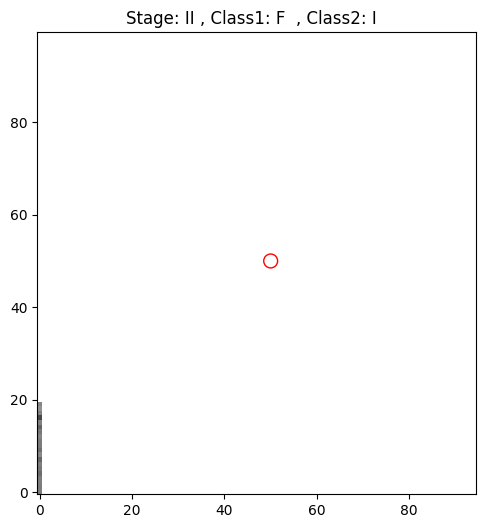

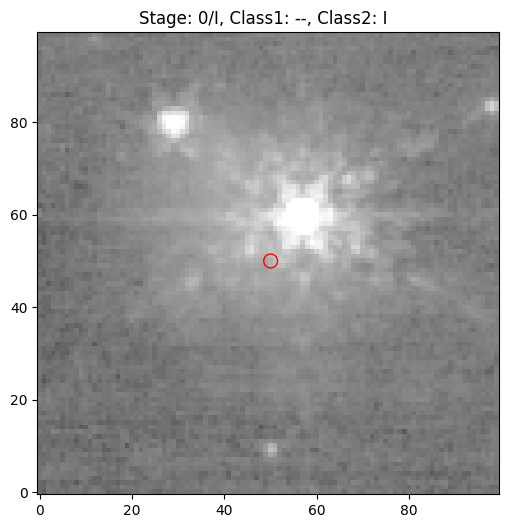

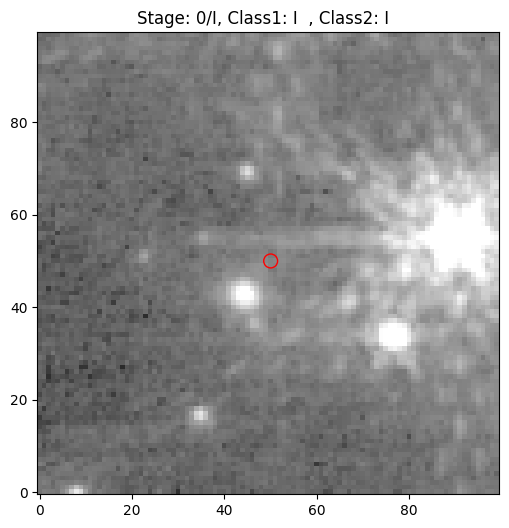

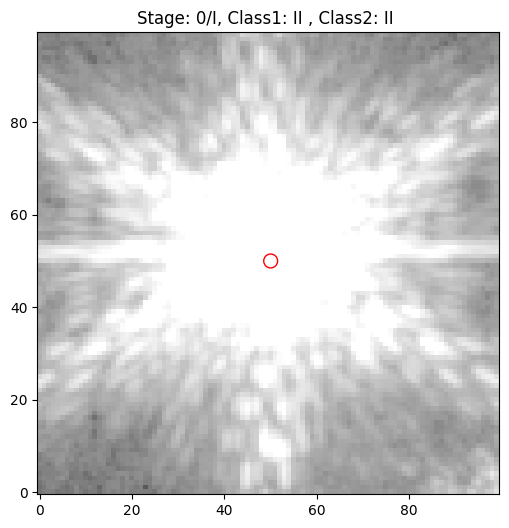

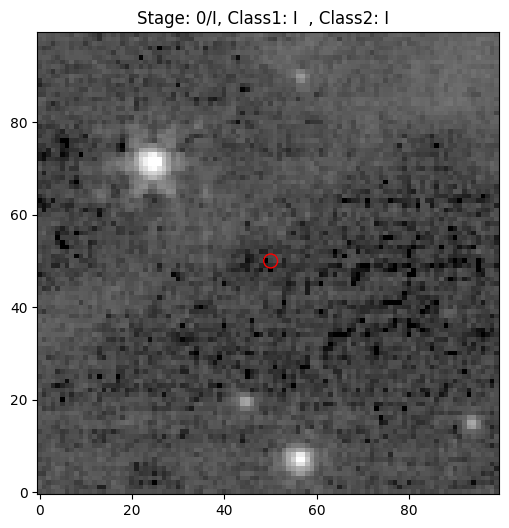

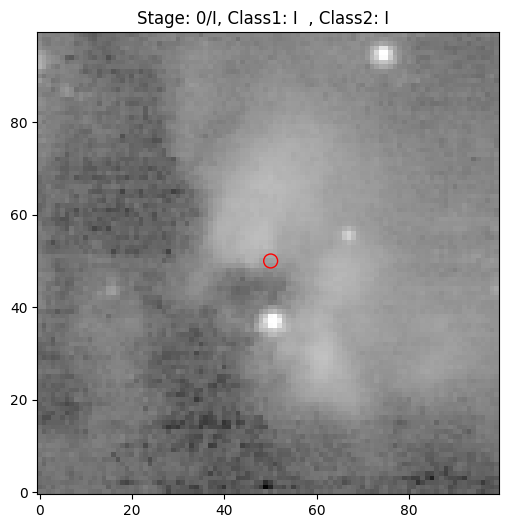

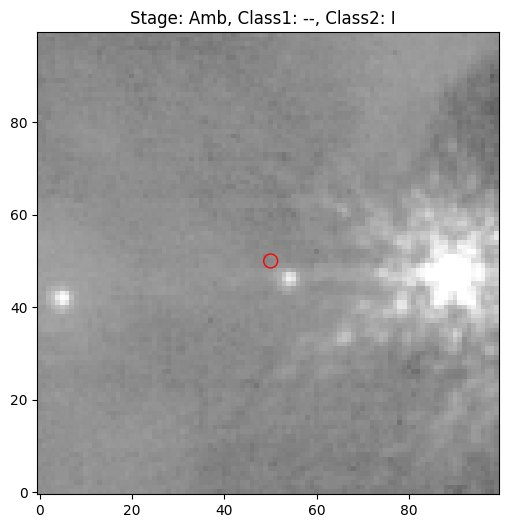

In [19]:
pixcoord_kang09_inside = (pixcoord_kang09[0][idx_inside], pixcoord_kang09[1][idx_inside])
stage_kang09_inside = stage_kang09[idx_inside]
class1_kang09_inside = class1_kang09[idx_inside]
class2_kang09_inside = class2_kang09[idx_inside]
#zoom in on the sources in Kang+09
for x, y, stage, class1, class2 in zip(pixcoord_kang09_inside[0], pixcoord_kang09_inside[1], stage_kang09_inside, class1_kang09_inside, class2_kang09_inside):
    x_min, x_max = int(x - 50), int(x + 50)
    y_min, y_max = int(y - 50), int(y + 50)
    
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    ax.imshow(img_f140m[y_min:y_max, x_min:x_max], origin='lower', cmap='gray', norm=norm)
    ax.scatter(50, 50, s=100, edgecolor='red', facecolor='none', label='Kang+09 Source')
    ax.set_title(f'Stage: {stage}, Class1: {class1}, Class2: {class2}')
    plt.show()